# Práctica 2. Análisis de los rendimientos en fabricación de queso mediante `Python`

## *Documento no definitivo, en elaboración*

En esta práctica utilizaremos un archivo de datos con diferentes valores analíticos para calcular los rendimientos queseros utilizando Python, y nos apoyaremos en diferentes tipos de gráficos para entenderlos.

En la práctica siguiente, utilizaremos los datos calculados aquí para hacer un balance de materia y calcular las pérdidas de nuestra fabricación.

[Abrir este cuaderno en Google Colab](https://colab.research.google.com/github/juanriera/master-queseria/blob/master/colab/090-pract02-rendimientos.ipynb)

[Descargar los datos de ejemplo utilizados en este cuaderno (archivo `fab_queso_bm_limpio.csv`)]((https://raw.githubusercontent.com/juanriera/master-queseria/master/datos/fab_queso_bm_limpio.csv'))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [3]:
url_datos = 'https://raw.githubusercontent.com/juanriera/master-queseria/master/datos/fab_queso_bm_limpio.csv'

try:
    df = pd.read_csv(url_datos, decimal = ",", sep=';', encoding='ISO-8859-1')
    print("¡Archivo ", url_datos," cargado correctamente!")
    print(f"Dimensiones de los datos: {df.shape}")
except Exception as e:
    print(f"Error al cargar el archivo: {e}")

¡Archivo  https://raw.githubusercontent.com/juanriera/master-queseria/master/datos/fab_queso_bm_limpio.csv  cargado correctamente!
Dimensiones de los datos: (45, 15)


In [4]:
# crear index con fecha
df['fecha_index'] = pd.to_datetime(
    df['fecha'], 
    format='%d/%m/%Y',  # Formato Día/Mes/Año confirmado
    errors='coerce'     # Clave: convierte los valores que no puede leer a NaT (Not a Time)
)
# 2. Limpiar NaT y establecer el índice
df.dropna(subset=['fecha_index'], inplace=True)
df.set_index('fecha_index', inplace=True)
df.sort_index(inplace=True)

In [6]:
df.head()

,fecha,receta,litros_past,kg_cuba,est_cuba,mg_cuba,mp_cuba,lactosa_cuba,ph_final_moldeo_cuba,formato,est_salida_salmuera,mg_salida_salmuera,ph_salida_salmuera,peso_queso_total,sal_queso,rendimiento_simple
0,23/02/2022,light,12330,12860.510,10.28,2.46,3.38,4.44,6.46,3 kg,50.85,20.34,5.44,1419.3,1.47,11.510949
1,24/02/2022,mezcla,7500,7704.462,12.80,4.90,3.89,4.01,6.35,barra,59.42,32.13,5.40,1062.4,1.31,14.165333
2,01/03/2022,light,13030,13867.370,10.41,2.47,3.43,4.51,6.40,barra,52.10,21.15,5.34,1536.0,1.17,11.788181
3,22/04/2022,vaca,13910,14382.290,12.76,4.97,3.93,3.86,NaN,barra,54.13,29.34,5.46,2228.0,1.59,16.017254
4,04/03/2022,oveja,11890,12344.190,14.37,5.86,4.55,3.96,6.42,barra,57.60,31.99,5.42,2051.0,NaN,17.249790


In [6]:
df['formato'].value_counts()

formato
barra    28
3 kg     13
500 g     4
Name: count, dtype: int64

In [7]:
df['receta'].value_counts()

receta
mezcla    11
light     10
oveja     10
vaca       9
i+D        5
Name: count, dtype: int64

Podemos calcular el rendimiento simple como los kilos de queso que podemos obtener con 100 L de leche

In [4]:
df['rendimiento_simple'] = df['peso_queso_total']/df['litros_past']*100

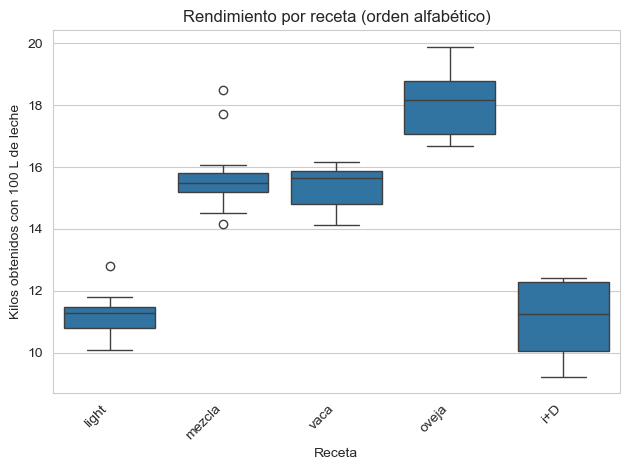

In [5]:

sns.boxplot(data=df, x='receta', y='rendimiento_simple')
plt.xticks(rotation=45, ha='right')
plt.title('Rendimiento por receta (orden alfabético)')
plt.xlabel('Receta')
plt.ylabel('Kilos obtenidos con 100 L de leche')
plt.tight_layout()
plt.show()


Aunque es más frecuente calcular el rendimiento simple como los litros de leche que necesitamos para hacer un kilo de queso

In [8]:
df['rendimiento_simple'] = df['litros_past']/df['peso_queso_total']

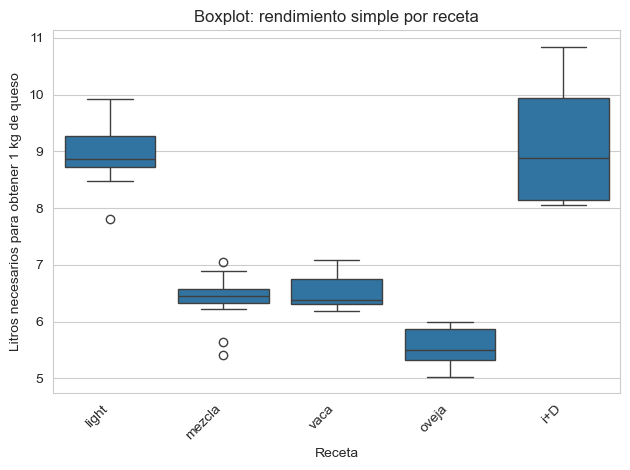

In [17]:
sns.boxplot(data=df, x='receta', y='rendimiento_simple')
plt.xticks(rotation=45, ha='right')
plt.title('Boxplot: rendimiento simple por receta')
plt.xlabel('Receta')
plt.ylabel('Litros necesarios para obtener 1 kg de queso')
plt.tight_layout()
plt.show()

El boxplot es muy útil para resumir grandes cantidades de información, pero cuando el número de puntos es muy bajo, puede resultarnos más útil la visualización mediante otro tipo de gráficos que nos muestren los puntos individuales agrupados. Entre estas visualizaciones, la biblioteca `Seaborn` nos ofrece el gráfico llamado *beeswarm* mediante la función `swarmplot()`, y también el *dotplot*, mediante la función `stripplot()`.

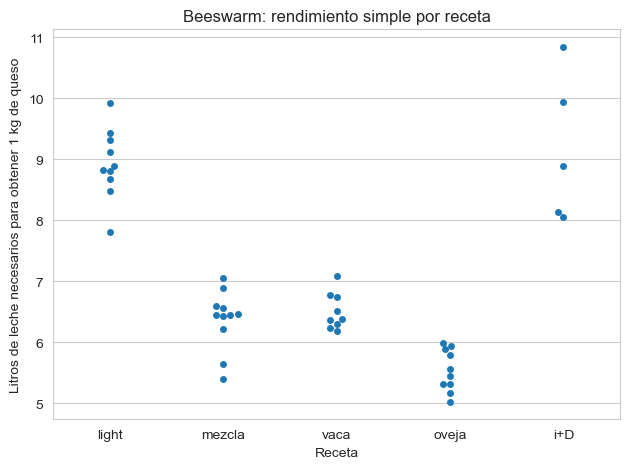

In [13]:
sns.swarmplot(data=df, x='receta', y='rendimiento_simple', size=5)
plt.xticks(rotation=0) # es opcional rotar lo rótulos para mejorar la visibilidad cuando los titulos son largos y se solapan
plt.title('Beeswarm: rendimiento simple por receta')
plt.xlabel('Receta')
plt.ylabel('Litros de leche necesarios para obtener 1 kg de queso')
plt.tight_layout()
plt.show()

El *stripplot* muestra los puntos en distribución vertical sobre las categorías; para evitar que los puntos con las mismas coordenada se solapen, utilizamos la opción *jitter*, que introduce un pequeño *ruido* aleatorio para desplazar las coordenadas de los puntos evitando su solapamiento.

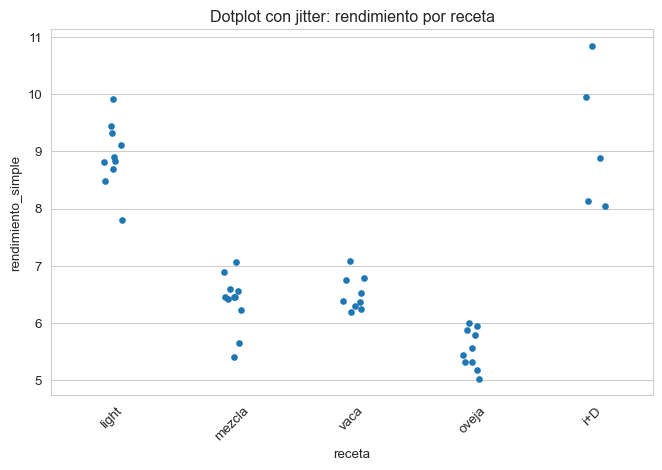

In [12]:
sns.stripplot(data=df, x='receta', y='rendimiento_simple', jitter=True, size=5)
plt.xticks(rotation=45)
plt.title('Dotplot con jitter: rendimiento por receta')
plt.tight_layout()
plt.show()

Este diagrama puede superponerse al *boxplot*, lo que nos permite completar la visualización de los puntos y la interpretación que hace el *boxplot* de su distribución.

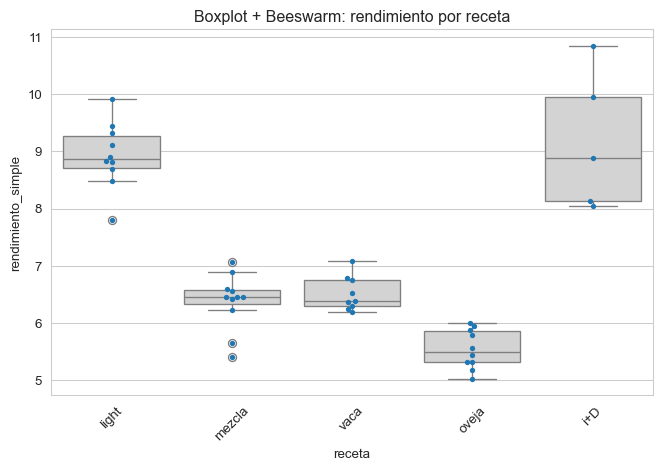

In [13]:
sns.boxplot(data=df, x='receta', y='rendimiento_simple', color='lightgray')
sns.swarmplot(data=df, x='receta', y='rendimiento_simple', size=4)
plt.xticks(rotation=45)
plt.title('Boxplot + Beeswarm: rendimiento por receta')
plt.tight_layout()
plt.show()

En este caso, seguiremos utilizando el *beeswarm*, y lo utilizaremos para ver si el formato en el que ha sido moldeado el queso puede haber influido en los valores de rendimiento obtenidos, para todos los productos, ¿quizás por pérdidas de producto en el moldeo?

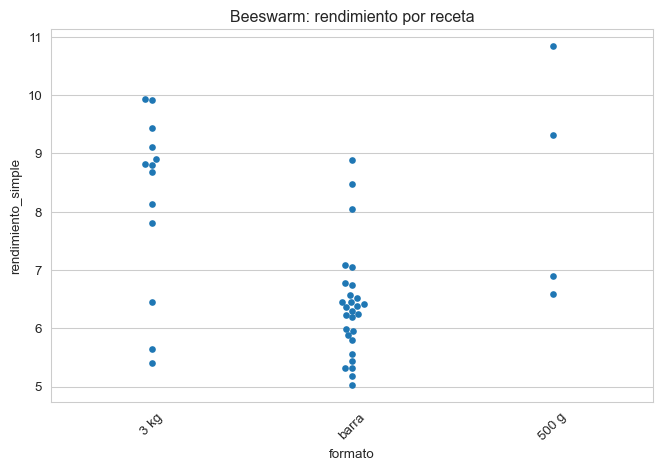

In [14]:
sns.swarmplot(data=df, x='formato', y='rendimiento_simple', size=5)
plt.xticks(rotation=45)
plt.title('Beeswarm: rendimiento por receta')
plt.tight_layout()
plt.show()

A la vista de la gráfica, parece que el moldeo en barra nos hace empeorar el rendimiento. Pero si miramos con más detalle, vemos que no es así. Si introducimos un código de color para cada receta, vemos que los rendimientos de las diferentes recetas son *aproximadamente* los mismos con independencia del formato.

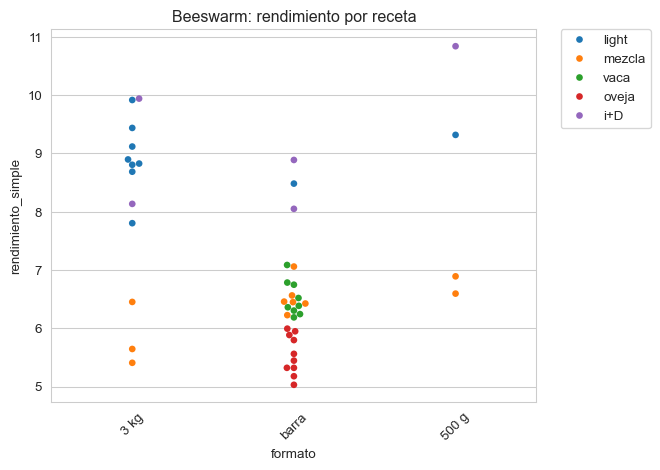

In [15]:
sns.swarmplot(data=df, x='formato', y='rendimiento_simple', hue='receta', size=5)
plt.xticks(rotation=45)
plt.title('Beeswarm: rendimiento por receta')

# Mover la leyenda fuera del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

Esto nos ayuda a comprender que no debemos sacar conclusiones apresuradas antes de haber completado el análisis detallado de la información disponible.

Volvamos al rendimiento; como estamos evaluando el rendimiento como los litros necesarios para obtener 1 kg de queso, resulta que la cantidad de agua que tenga el queso nos influye en el cálculo: cuanto más húmedo el queso, más favorable será el valor el rendimiento simple. Veamos las diferencias entre recetas.

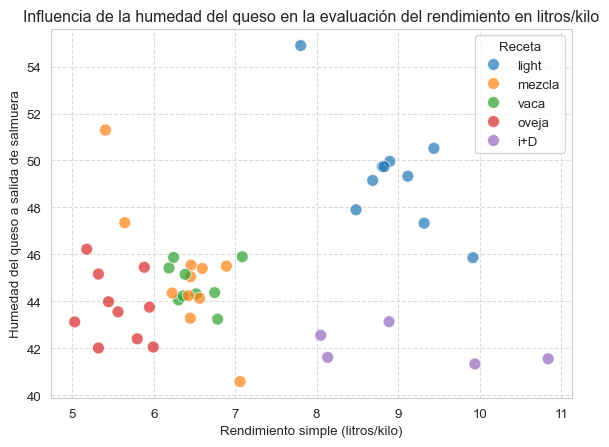

In [16]:
df['humedad_salida_salmuera'] = 100 - df['est_salida_salmuera'] 

df_plot_sns = df.reset_index(drop=True)
sns.scatterplot(data=df_plot_sns, x='rendimiento_simple', y='humedad_salida_salmuera', hue='receta', s=80, alpha=0.7)
plt.title('Influencia de la humedad del queso en la evaluación del rendimiento en litros/kilo')
plt.xlabel('Rendimiento simple (litros/kilo)')
plt.ylabel('Humedad del queso a salida de salmuera')
plt.legend(title='Receta') # Mostrar leyenda para la especie
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Por esta razón, debemos calcular el rendimiento mediante parámetros que no se vean afectados por lacomposición del queso. La mejor forma de hacer el cálculo del rendimiento es calcular el porcentaje de materia quesera que hemos sido capaces de retener en el queso; consideraremos la recuperación de materia grasa, de materia proteica y de extracto seco magro. Estos valores son propios de cada tecnología quesera, y sirven de referencia para comprender cuáles son los diferentes problemas en fabricación:

* Una mala retención de materia grasa
* Una mala retención de proteína
* Una mala retención de extracto seco magro

Realicemos todos los cálculos en un solo bloque.

In [20]:
### 1. Cálculos de Entrada
df['est_kg_cuba'] = df['kg_cuba'] * df['est_cuba'] / 100
df['mg_kg_cuba'] = df['kg_cuba'] * df['mg_cuba'] / 100
df['mp_kg_cuba'] = df['kg_cuba'] * df['mp_cuba'] / 100
df['esm_kg_cuba'] = df['est_kg_cuba'] - df['mg_kg_cuba'] 

### 2. Cálculos de Salida
df['est_kg_queso'] = df['peso_queso_total'] * df['est_salida_salmuera'] / 100
df['mg_kg_queso'] = df['peso_queso_total'] * df['mg_salida_salmuera'] / 100
df['esm_kg_queso'] = df['est_kg_queso'] - df['mg_kg_queso']
df['sal_kg_queso'] = df['peso_queso_total'] * df['sal_queso']/100

### 3. Balance de Materia (Salida - Entrada)
# La falta de producto queda como negativo al hacer Salida - Entrada
df['balance_est'] = df['est_kg_queso'] - df['est_kg_cuba']
df['balance_mg'] = df['mg_kg_queso'] - df['mg_kg_cuba']
df['balance_esm'] = df['esm_kg_queso'] - df['esm_kg_cuba'] - df['sal_kg_queso']

### 4. Coeficientes de recuperación
df['coef_recup_mg']  = df['mg_kg_queso']/df['mg_kg_cuba']
df['coef_recup_mp']  = df['esm_kg_queso']/df['mp_kg_cuba'] # atencion a la fórmula de cálculo, deberia ser mp_kg_queso
df['coef_recup_esm'] = df['esm_kg_queso']/df['esm_kg_cuba']

### 5. Consumos de materia por kilo de queso
df['consumo_mg_kg'] = df['mg_kg_cuba'] / df['peso_queso_total'] * 1000
df['consumo_mp_kg'] = df['mp_kg_cuba'] / df['peso_queso_total'] * 1000

### 6. Preparación y Exportación del DataFrame de Resultados
# Columnas finales a incluir en el reporte
columnas_balance = [
    'receta', 'formato',
    'litros_past', 'peso_queso_total',
    'est_kg_cuba', 'est_kg_queso', 
    'mg_kg_cuba', 'mg_kg_queso', 
    'mp_kg_cuba',
    'esm_kg_cuba', 'esm_kg_queso', 
    'balance_est', 'balance_mg', 'balance_esm',
    'coef_recup_mg', 'coef_recup_mp', 'coef_recup_esm',
    'consumo_mg_kg', 'consumo_mp_kg'
]

# Crear un nuevo DataFrame con las columnas de interés
df_balance = df[columnas_balance].copy()

# Guardar el DataFrame con punto decimal y separador ';'
nombre_archivo_salida = 'datos/informe_balance_materia.csv'

df_balance.to_csv(
    nombre_archivo_salida, 
    sep=';', 
    index=False,
    decimal=','
)

print(f"✅ Balance de materia y consumos de materia calculados, guardado en **{nombre_archivo_salida}** (separador ';', decimal ',').")
print("\n--- Resumen de los Balances (Primeras 5 Filas) ---")
# Imprimimos solo las columnas de balance para verificar
print(df_balance[['receta', 'balance_est', 'balance_mg', 'balance_esm']].round(2).head())


✅ Balance de materia y consumos de materia calculados, guardado en **datos/informe_balance_materia.csv** (separador ';', decimal ',').

--- Resumen de los Balances (Primeras 5 Filas) ---
   receta  balance_est  balance_mg  balance_esm
0   light      -600.35      -27.68      -593.53
1  mezcla      -354.89      -36.17      -332.64
2   light      -643.34      -17.66      -643.65
3    vaca      -629.16      -61.10      -603.48
4   oveja      -592.48      -67.25          NaN


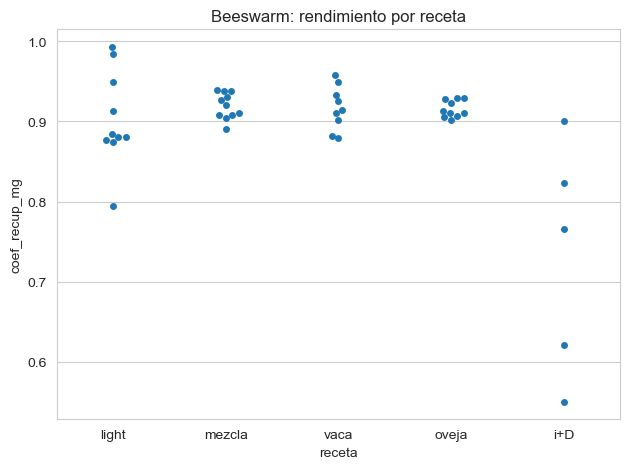

In [22]:
df_balance_sns = df_balance.reset_index(drop=True)

sns.swarmplot(data=df_balance_sns, x='receta', y='coef_recup_mg', size=5)
plt.xticks(rotation=0)
plt.title('Beeswarm: rendimiento por receta')
plt.tight_layout()
plt.show()

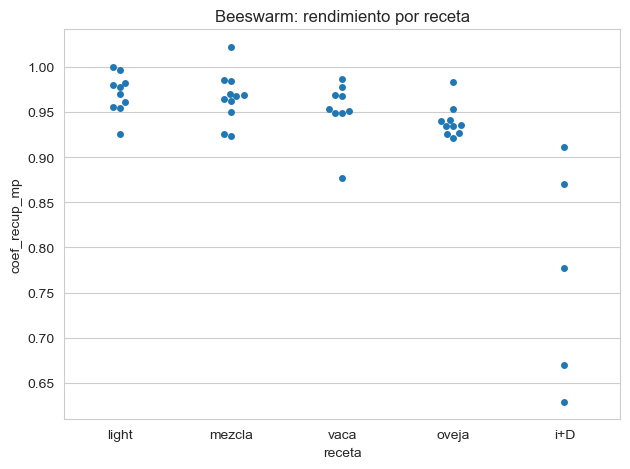

In [23]:
sns.swarmplot(data=df_balance_sns, x='receta', y='coef_recup_mp', size=5)
plt.xticks(rotation=0)
plt.title('Beeswarm: rendimiento por receta')
plt.tight_layout()
plt.show()

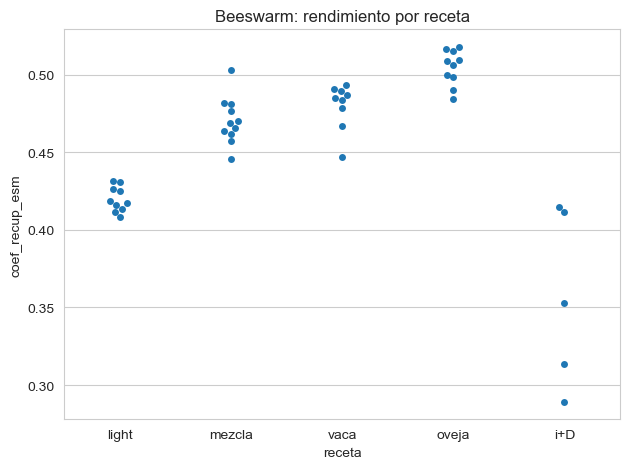

In [24]:
sns.swarmplot(data=df_balance_sns, x='receta', y='coef_recup_esm', size=5)
plt.xticks(rotation=0)
plt.title('Beeswarm: rendimiento por receta')
plt.tight_layout()
plt.show()

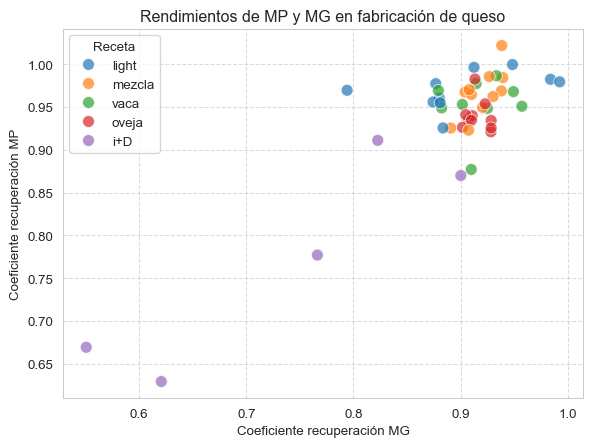

In [21]:
sns.scatterplot(data=df_balance_sns, x='coef_recup_mg', y='coef_recup_mp', hue='receta', s=80, alpha=0.7)
plt.title('Rendimientos de MP y MG en fabricación de queso')
plt.xlabel('Coeficiente recuperación MG')
plt.ylabel('Coeficiente recuperación MP')
plt.legend(title='Receta') # Mostrar leyenda para la especie
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Filtremos los resultados de i+D que no son relevantes para nuestro análisis y están distorionando la escala del gráfico.

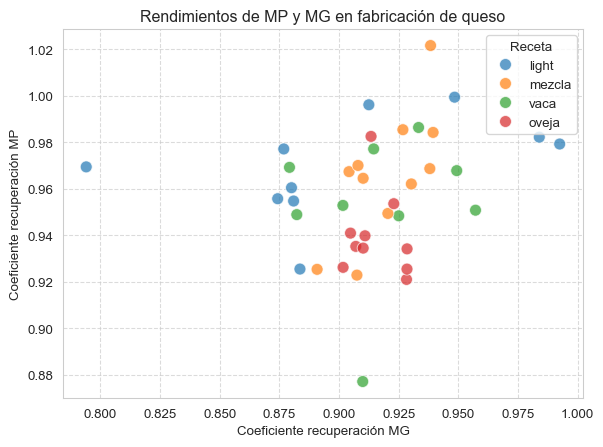

In [22]:
sns.scatterplot(data=df_balance[df_balance['receta'] != 'i+D'], 
                x='coef_recup_mg', 
                y='coef_recup_mp', 
                hue='receta', 
                s=80, 
                alpha=0.7)
plt.title('Rendimientos de MP y MG en fabricación de queso')
plt.xlabel('Coeficiente recuperación MG')
plt.ylabel('Coeficiente recuperación MP')
plt.legend(title='Receta') # Mostrar leyenda para la especie
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Calculemos los centroides de cada grupo (receta) mediante la mediana.

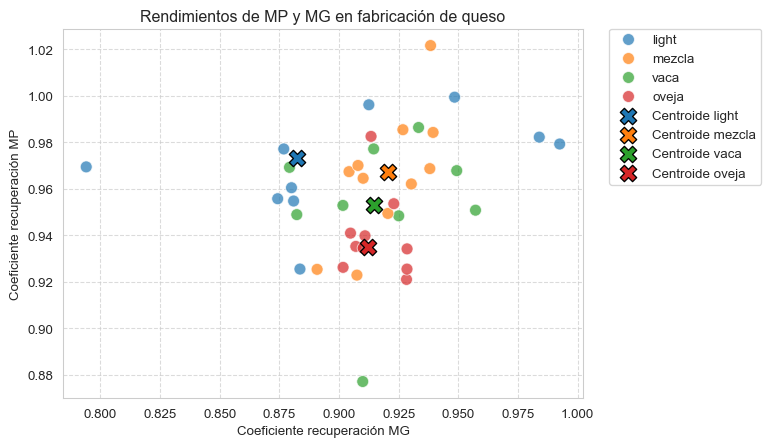

In [23]:

# Filtrar receta 'i+D'
df_filtrado = df[df['receta'] != 'i+D'].reset_index(drop=True)

# Crear paleta de colores por receta
recetas = df_filtrado['receta'].unique()
palette = sns.color_palette('tab10', n_colors=len(recetas))
color_dict = dict(zip(recetas, palette))

sns.scatterplot(data=df_balance[df_balance['receta'] != 'i+D'], 
                x='coef_recup_mg', 
                y='coef_recup_mp', 
                hue='receta', 
                palette = color_dict,
                s=80, 
                # edgecolor = 'black',
                alpha=0.7)

# Calcular y dibujar centroides
centroides = df.groupby('receta')[['coef_recup_mg', 'coef_recup_mp']].median()

for receta in recetas:
    centro = centroides.loc[receta]
    plt.scatter(
        centro['coef_recup_mg'],
        centro['coef_recup_mp'],
        color=color_dict[receta],
        marker='X',
        s=150,
        edgecolor='black',
        label=f'Centroide {receta}'
    )

plt.title('Rendimientos de MP y MG en fabricación de queso')
plt.xlabel('Coeficiente recuperación MG')
plt.ylabel('Coeficiente recuperación MP')
plt.legend(title='Receta') # Mostrar leyenda para la especie
# Mover la leyenda fuera del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


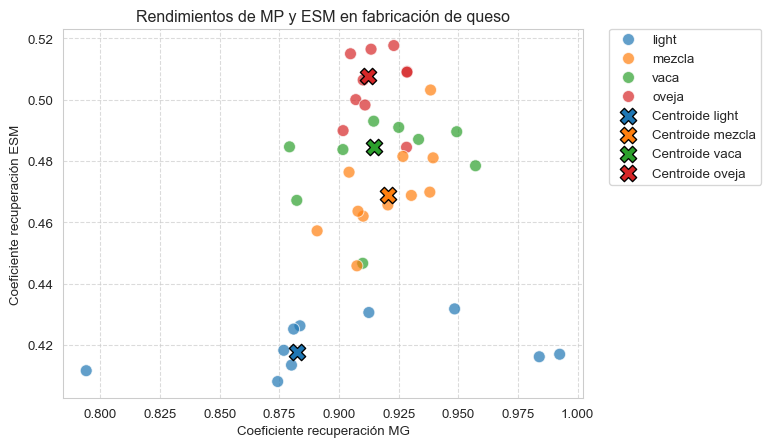

In [24]:
sns.scatterplot(data=df_balance[df_balance['receta'] != 'i+D'], 
                x='coef_recup_mg', 
                y='coef_recup_esm', 
                hue='receta', 
                palette = color_dict,
                s=80, 
                # edgecolor = 'black',
                alpha=0.7)

# Calcular y dibujar centroides
centroides = df.groupby('receta')[['coef_recup_mg', 'coef_recup_esm']].median()

for receta in recetas:
    centro = centroides.loc[receta]
    plt.scatter(
        centro['coef_recup_mg'],
        centro['coef_recup_esm'],
        color=color_dict[receta],
        marker='X',
        s=150,
        edgecolor='black',
        label=f'Centroide {receta}'
    )

plt.title('Rendimientos de MP y ESM en fabricación de queso')
plt.xlabel('Coeficiente recuperación MG')
plt.ylabel('Coeficiente recuperación ESM')
plt.legend(title='Receta') # Mostrar leyenda para la especie
# Mover la leyenda fuera del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [25]:
# 1. Crear la columna 'semana' usando el formato ISO (Lunes=Día 1)
# Usamos el índice del DataFrame (que debe ser DatetimeIndex)
df['semana_iso'] = df.index.strftime('%G-W%V') 

print("✅ Columna 'semana_iso' creada con el estándar Lunes-Domingo.")

✅ Columna 'semana_iso' creada con el estándar Lunes-Domingo.


In [26]:
# Columnas que queremos sumarizar (Balances + Entradas + Salidas)
columnas_a_sumarizar = [
    # Entradas
    'est_kg_cuba', 'mg_kg_cuba', 'esm_kg_cuba',
    # Salidas
    'est_kg_queso', 'mg_kg_queso', 'esm_kg_queso',
    # Balances
    'balance_est', 'balance_mg', 'balance_esm'
]

# 2. Agrupar por 'semana_iso' y 'receta' y calcular la SUMA de todas las columnas
df_balance_semanal_completo = df.groupby(['semana_iso', 'receta'])[columnas_a_sumarizar].sum()

# Renombrar las columnas para indicar que son totales
df_balance_semanal_completo.columns = [f'total_{col}' for col in columnas_a_sumarizar]

print("\n--- Balance Completo Semanal ISO por Receta (Primeras 5 Filas) ---")
print(df_balance_semanal_completo.head().round(2))


--- Balance Completo Semanal ISO por Receta (Primeras 5 Filas) ---
                   total_est_kg_cuba  total_mg_kg_cuba  total_esm_kg_cuba  \
semana_iso receta                                                           
2022-W08   light             1322.06            316.37            1005.69   
           mezcla             986.17            377.52             608.65   
2022-W09   light             1443.59            342.52            1101.07   
           mezcla            1923.33            734.85            1188.48   
           oveja             1773.86            723.37            1050.49   

                   total_est_kg_queso  total_mg_kg_queso  total_esm_kg_queso  \
semana_iso receta                                                              
2022-W08   light               721.71             288.69              433.03   
           mezcla              631.28             341.35              289.93   
2022-W09   light               800.26             324.86              47

In [27]:
# 1. Definir el nombre del archivo de salida
nombre_archivo_final = 'datos/reporte_balance_completo_semanal_iso.csv'

# 2. Exportar el DataFrame a CSV
df_balance_semanal_completo.to_csv(
    nombre_archivo_final, 
    sep=';',        # Usa punto y coma como separador de columnas
    index=True,     # Mantiene las columnas de agrupación ('semana_iso' y 'receta')
    decimal=','     # Usa punto como separador decimal
)

print(f"✅ Reporte de balance completo semanal guardado como **{nombre_archivo_final}**.")

✅ Reporte de balance completo semanal guardado como **datos/reporte_balance_completo_semanal_iso.csv**.
